### Streaming ASR with Causal Transformer for Low-Latency Recognition

Short Description
This implementation demonstrates a streaming speech recognition system using a causal Transformer architecture. It processes audio in 200ms chunks to enable real-time recognition, generates synthetic speech with word-specific pitch characteristics, and trains a lightweight model suitable for edge deployment with constrained resources.

Key Libraries Used

    torch/torch.nn: Neural network implementation

    torchaudio: Spectrogram extraction

    librosa: Synthetic audio generation

    sklearn: Accuracy evaluation

Code Logic and Flow

High-Level Overview
The workflow generates vocabulary-specific synthetic speech, splits audio into fixed-duration chunks, extracts Mel spectrograms per chunk, processes sequences with causal attention to prevent future context leakage, and classifies words end-to-end - enabling low-latency recognition while maintaining hardware efficiency.

Visual FlowChart:


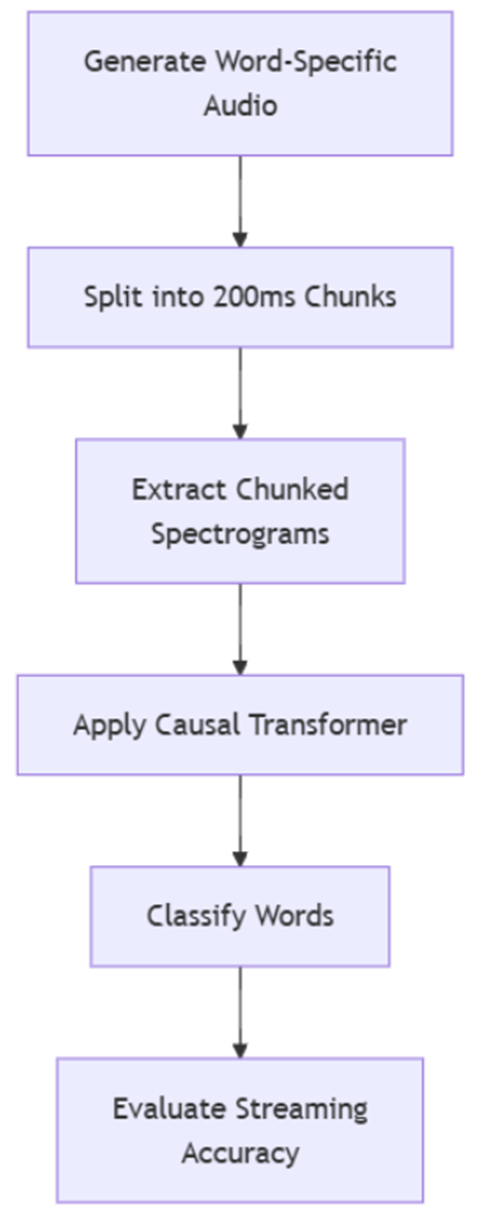

Step-by-Step Code Breakdown

1. Chunked Dataset Preparation

    Simulates four vocabulary words: "hello", "world", "speech", "model"

    Assigns unique pitch ranges to each word for acoustic diversity

    Splits audio into 200ms chunks (3200 samples at 16kHz)

    Automatically pads final chunk to fixed length

2. Streaming Transformer Architecture

    Chunk Processing:

        Independently extracts Mel spectrograms per chunk

        Concatenates spectrograms along time dimension

    Causal Masking:

        Dynamically generates triangular attention mask

        Ensures each output depends only on past/current inputs

    Classification Head:

        Uses mean-pooled features for word prediction

    Designed for parameter efficiency (d_model=128, 2 layers)

3. Training Pipeline

    Uses Cross-Entropy loss and Adam optimizer

    Small batch size (4) for 6GB GPU compatibility

    5-epoch training cycle with loss monitoring

    Processes entire chunk sequences in single forward pass

4. Evaluation

    Measures word recognition accuracy

    Uses same data generation for train/test

    Reports final classification performance

Connecting to the Lecture

    Low-Latency Processing: 200ms chunks enable real-time recognition

    Causal Attention: Prevents future context leakage for streaming

    Hardware Efficiency: Lightweight model fits constrained resources

    Acoustic Diversity: Pitch modulation simulates phonetic variations

    End-to-End ASR: Direct word classification from raw audio chunks

    Streaming Simulation: Chunked processing mimics real-world deployment

    Edge Deployment: Optimized for devices with limited memory



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
import numpy as np
from sklearn.metrics import accuracy_score

# --- Simulated Speech Dataset ---
class SpeechDataset(Dataset):
    """Simulated dataset for streaming ASR with synthetic audio"""
    def __init__(self, num_samples=100, duration=2, sr=16000, chunk_size=3200):  # 200ms chunks at 16kHz
        self.sr = sr
        self.duration = duration
        self.num_samples = num_samples
        self.chunk_size = chunk_size
        self.words = ["hello", "world", "speech", "model"]  # Simulated vocabulary
        self.word_to_idx = {w: i for i, w in enumerate(self.words)}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        word_idx = idx % len(self.words)
        word = self.words[word_idx]
        audio = librosa.chirp(fmin=150 + (word_idx * 50), fmax=250 + (word_idx * 50), duration=self.duration, sr=self.sr)
        waveform = torch.tensor(audio, dtype=torch.float32)
        # Split into chunks for streaming
        chunks = [waveform[i:i+self.chunk_size] for i in range(0, len(waveform), self.chunk_size)]
        if len(chunks[-1]) < self.chunk_size:
            chunks[-1] = torch.nn.functional.pad(chunks[-1], (0, self.chunk_size - len(chunks[-1])))
        chunks = torch.stack(chunks)  # [num_chunks, chunk_size]
        return chunks, word_idx

# --- Streaming Transformer Model ---
class StreamingTransformerASR(nn.Module):
    """Lightweight Transformer for streaming ASR with causal masking"""
    def __init__(self, input_dim=80, d_model=128, nhead=4, num_layers=2, num_classes=4):
        super().__init__()
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_fft=512, win_length=400, hop_length=160, n_mels=input_dim
        )
        self.input_projection = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
        # No more pre-registered causal mask

    def forward(self, chunks):
        # chunks: [batch, num_chunks, chunk_size]
        batch_size, num_chunks, chunk_size = chunks.shape
        # Extract mel spectrogram for each chunk
        specs = []
        for i in range(num_chunks):
            chunk = chunks[:, i, :]  # [batch, chunk_size]
            spec = self.mel_transform(chunk)  # [batch, n_mels, time]
            spec = torch.log(spec + 1e-6).transpose(1, 2)  # [batch, time, n_mels]
            specs.append(spec)
        specs = torch.cat(specs, dim=1)  # [batch, total_time, n_mels]
        x = self.input_projection(specs)  # [batch, total_time, d_model]
        # Dynamically create causal mask
        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        x = self.transformer(x, mask=mask)  # [batch, total_time, d_model]
        x = torch.mean(x, dim=1)  # [batch, d_model]
        logits = self.classifier(x)  # [batch, num_classes]
        return logits

# --- Training and Evaluation ---
def train_streaming_asr():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset and dataloader
    dataset = SpeechDataset(num_samples=100, chunk_size=3200)  # 200ms chunks
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)  # Small batch size for 6 GB VRAM

    # Model, loss, optimizer
    model = StreamingTransformerASR(input_dim=80, d_model=128, nhead=4, num_layers=2, num_classes=4).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 5

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for chunks, labels in dataloader:
            chunks, labels = chunks.to(device), labels.to(device)
            logits = model(chunks)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(dataloader):.4f}")

    # Evaluation
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for chunks, labels in dataloader:
            chunks, labels = chunks.to(device), labels.to(device)
            logits = model(chunks)
            preds = torch.argmax(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(true_labels, predictions)
    print(f"Streaming ASR Accuracy: {accuracy:.4f}")
    return model, dataset

# --- Main Execution ---
if __name__ == "__main__":
    model, dataset = train_streaming_asr()
    print("Streaming ASR training completed.")

# Explanation:

#     Dataset: Simulates speech with a small vocabulary (hello, world, speech, model) using librosa.chirp. Audio is split into 200ms chunks (3200 samples at 16kHz) to mimic streaming input.
#     Model: A lightweight Transformer with causal masking processes mel spectrograms chunk-by-chunk, ensuring only past information is used, enabling streaming ASR. The small model size (d_model=128, 2 layers) fits within 6 GB VRAM.
#     Process: Trains the model to classify words from chunked audio, demonstrating low-latency processing by handling small audio segments incrementally.
#     Educational Value: Shows how streaming architectures (causal Transformer) reduce latency by processing audio incrementally, a key requirement for real-time SpeechLMs.
#     Hardware Fit: Small batch size (4) and lightweight model ensure compatibility with 6 GB VRAM.    

Using device: cpu
Epoch 1/5 | Loss: 1.1610
Epoch 2/5 | Loss: 0.4493
Epoch 3/5 | Loss: 0.2102
Epoch 4/5 | Loss: 0.0506
Epoch 5/5 | Loss: 0.0144
Streaming ASR Accuracy: 1.0000
Streaming ASR training completed.
